In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import grangercausalitytests
import seaborn as sns



In [93]:
# Read in targets
targets_df = pd.read_csv('targets.csv')
targets_df['Date'] = pd.to_datetime(targets_df['Date'])
targets_df.set_index('Date', inplace=True)

# Read in predictors
predictors_df = pd.read_csv('predictors.csv')
predictors_df['Date'] = pd.to_datetime(predictors_df['Date'])
predictors_df.set_index('Date', inplace=True)

# Merge targets and predictors
merged_df = targets_df.join(predictors_df)
print(merged_df)

                     SO2    Auto Gas  Basic Chemicals    Fuel Oil  \
Date                                                                
1980-01-01  9.442626e-07   80.378294        86.835593   74.154677   
1980-04-01  9.340424e-07   74.045325        85.576519   66.056135   
1980-07-01  9.258992e-07   73.681244        80.152687   67.456106   
1980-10-01  9.199498e-07   73.421459        84.307597   70.289212   
1981-01-01  9.140747e-07   73.734122        86.152397   71.410456   
...                  ...         ...              ...         ...   
2022-10-01  3.424376e-07   98.531831        95.815294  102.555111   
2023-01-01  3.424159e-07   95.767037        99.619374   94.950619   
2023-04-01  3.424292e-07  101.908704        99.798314   99.925258   
2023-07-01  3.424477e-07  101.979881       100.576745  101.991806   
2023-10-01  3.424376e-07  100.344378       100.005567  103.132316   

            Manufacturing  Pave Roof PC  Petrol Coal  Total Population  \
Date                        

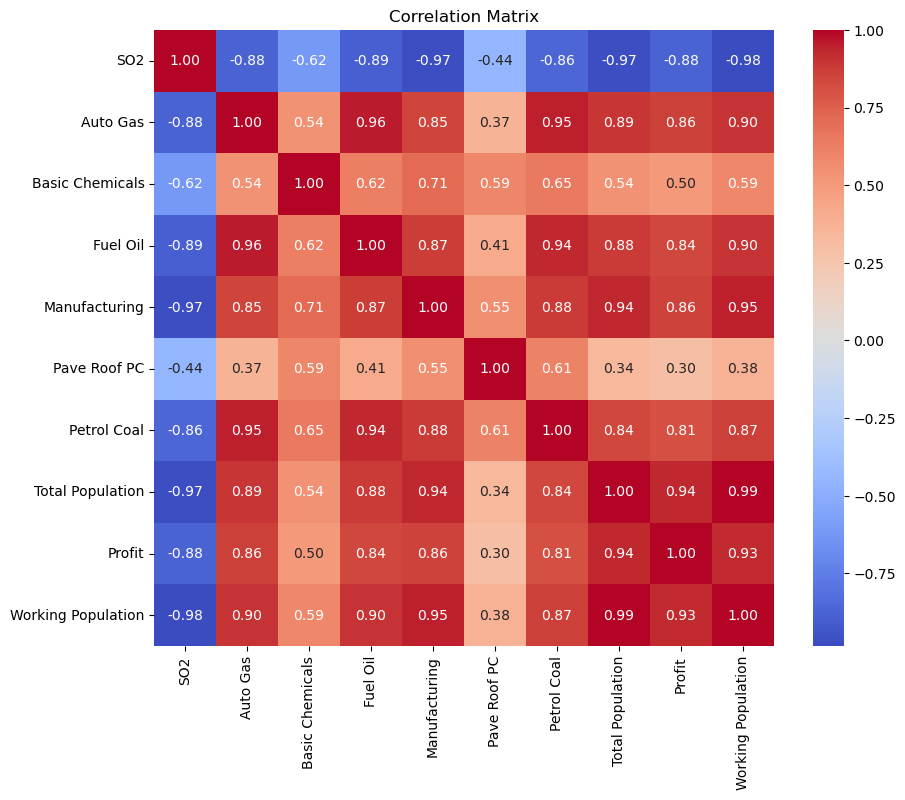

In [94]:
# Calculate correlation matrix
correlation_matrix = merged_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [95]:
# print(correlation_matrix)
# Features to include in analysis: 'Auto Gas', 'Manufacturing', 'Petrol Coal', 'Profit', 'Working Population'. 
# Given that the SO2 emissions are decreasing with increasing production index of industrial manufacturing sectors, corporate profit, and working population, 
# We now hypothesize that there are external factors that might be linked to the reduction of SO2 such as environmental regulation.
# We suggest that future work includes an analysis of environmental regulatory data in order to determine what role environmental protection efforts play in the results we presented here. 


# Let's drop all the unecessary features

In [96]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a new df with just the predictors of interest
selected_predictors = ['Auto Gas', 'Manufacturing', 'Petrol Coal', 'Profit', 'Working Population']
merged_df = merged_df[['SO2'] + selected_predictors]

# Calculate VIF for each predictor
predictors_df = merged_df[selected_predictors]
vif_data = pd.DataFrame()
vif_data["Feature"] = predictors_df.columns
vif_data["VIF"] = [variance_inflation_factor(predictors_df.values, i) for i in range(predictors_df.shape[1])]

# Display VIF values
print(vif_data)

              Feature         VIF
0            Auto Gas  794.855105
1       Manufacturing  106.664989
2         Petrol Coal  797.236141
3              Profit   25.961043
4  Working Population  342.922600


In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


# def perform_STL(df, feature):
#     # Perform STL decomposition
#     decomposition = seasonal_decompose(df[feature], model='multiplicative')

#     # Visualize the components
#     plt.figure(figsize=(10, 6))

#     plt.subplot(411)
#     plt.plot(decomposition.observed, label='Observed')
#     plt.legend(loc='upper left')

#     plt.subplot(412)
#     plt.plot(decomposition.trend, label='Trend')
#     plt.legend(loc='upper left')

#     plt.subplot(413)
#     plt.plot(decomposition.seasonal, label='Seasonal')
#     plt.legend(loc='upper left')

#     plt.subplot(414)
#     plt.plot(decomposition.resid, label='Residual')
#     plt.legend(loc='upper left')

#     plt.suptitle(f'STL Decomposition of {feature}')
#     plt.tight_layout()
#     plt.show()

def perform_multi_STL(df, features):
    # Create subplots
    fig, axs = plt.subplots(4, 1, figsize=(20, 10))

    # Perform STL decomposition for each feature
    for feature in features:
        decomposition = seasonal_decompose(df[feature], model='multiplicative')

        # Plot observed
        axs[0].plot(decomposition.observed, label=feature)
        axs[0].set_title('Observed')
        axs[0].legend(loc='upper left')

        # Plot trend
        axs[1].plot(decomposition.trend, label=feature)
        axs[1].set_title('Trend')
        axs[1].legend(loc='upper left')

        # Plot seasonal
        axs[2].plot(decomposition.seasonal, label=feature)
        axs[2].set_title('Seasonal')
        axs[2].legend(loc='upper left')

        # Plot residual
        axs[3].plot(decomposition.resid, label=feature)
        axs[3].set_title('Residual')
        axs[3].legend(loc='upper left')

    # Set common title and adjust layout
    plt.suptitle('')
    plt.tight_layout()
    plt.show()


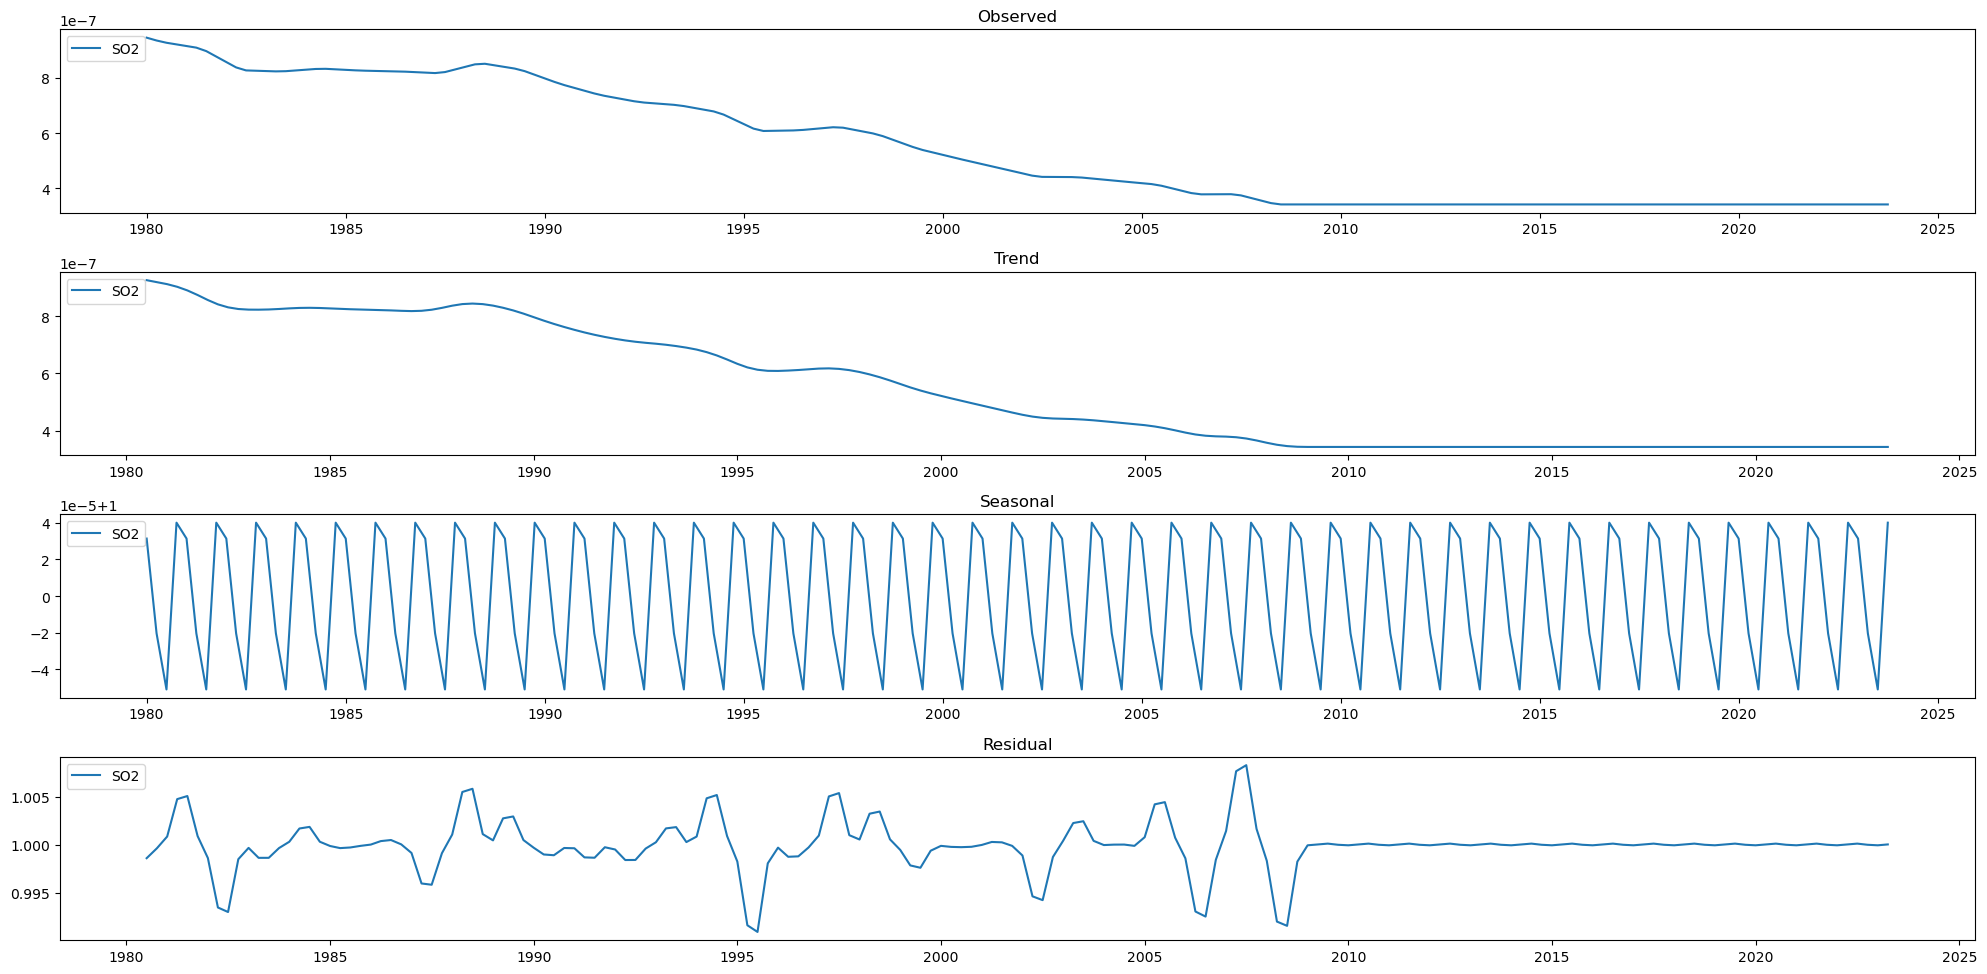

In [98]:
# perform_STL(merged_df, 'SO2')
perform_multi_STL(merged_df, ['SO2'])


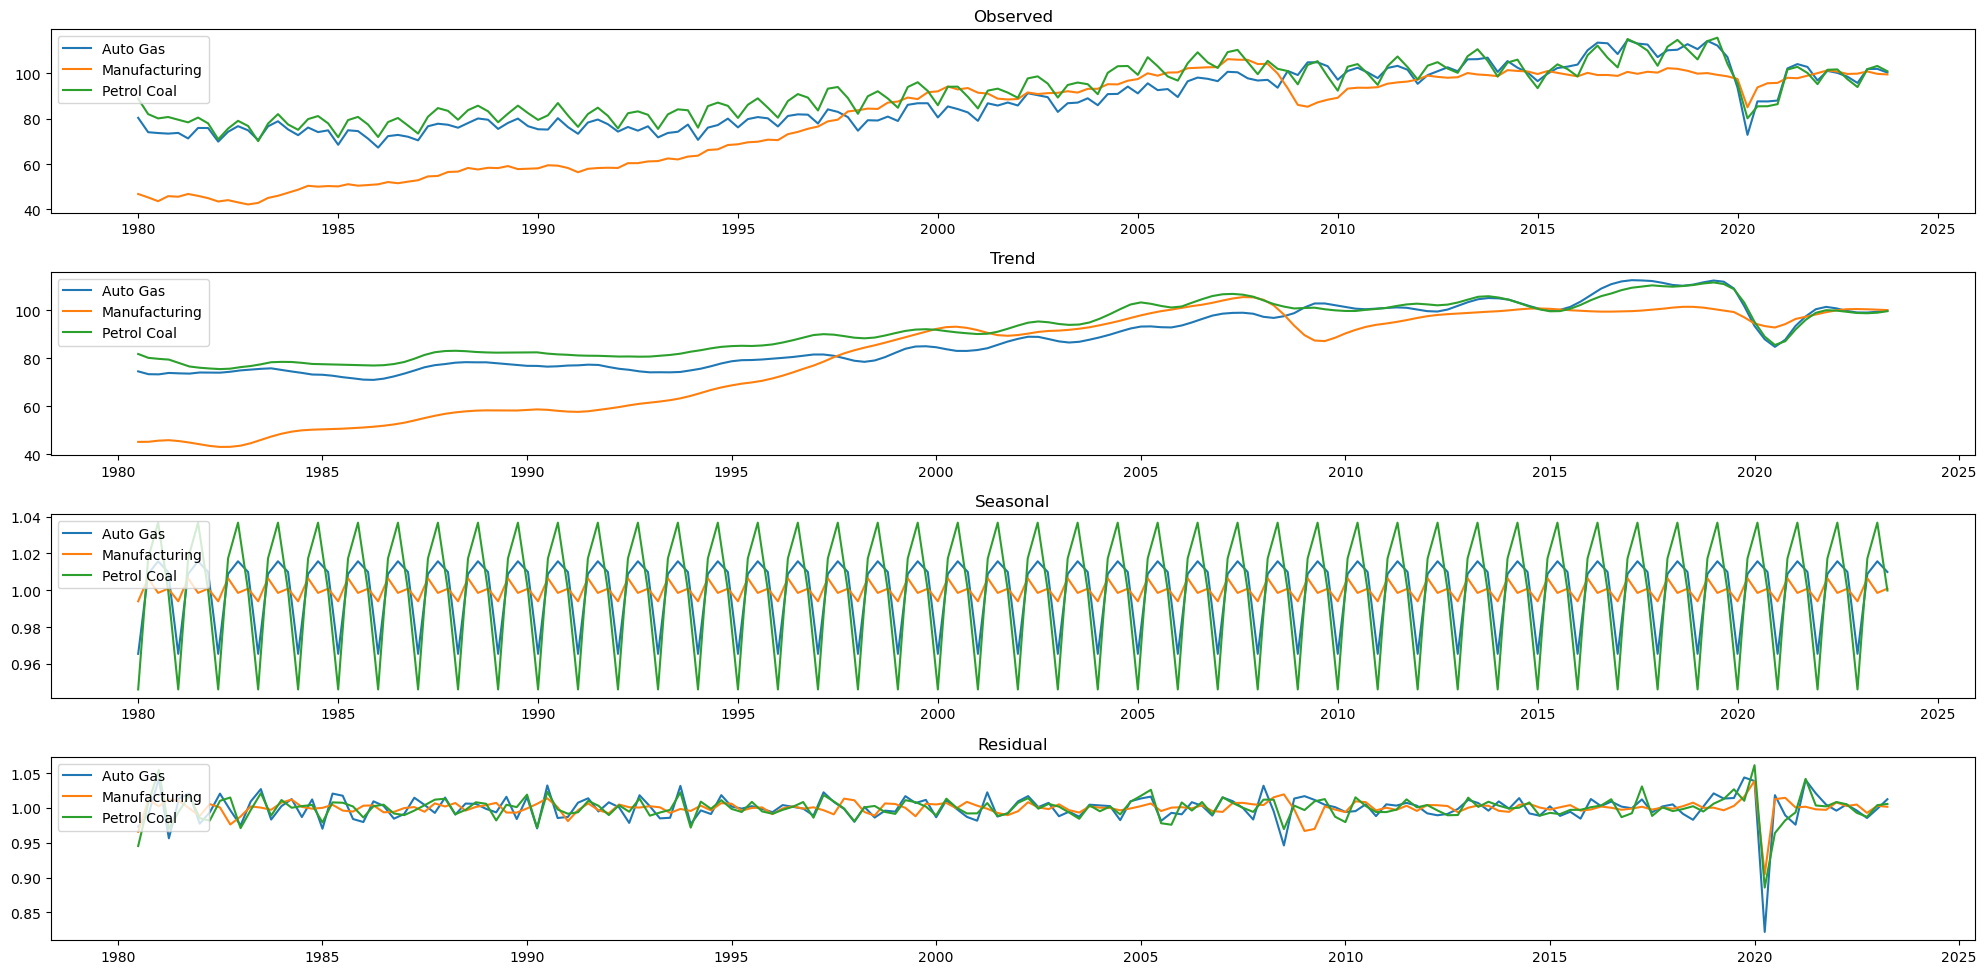

In [99]:
 # Call the function to perform STL decomposition and plot the selected predictors
perform_multi_STL(predictors_df, ['Auto Gas', 'Manufacturing', 'Petrol Coal'])  # maybe let's leave out fuel oil because it's pretty much the same as auto gas, but it appears to have a lag that I don't want to deal with. 


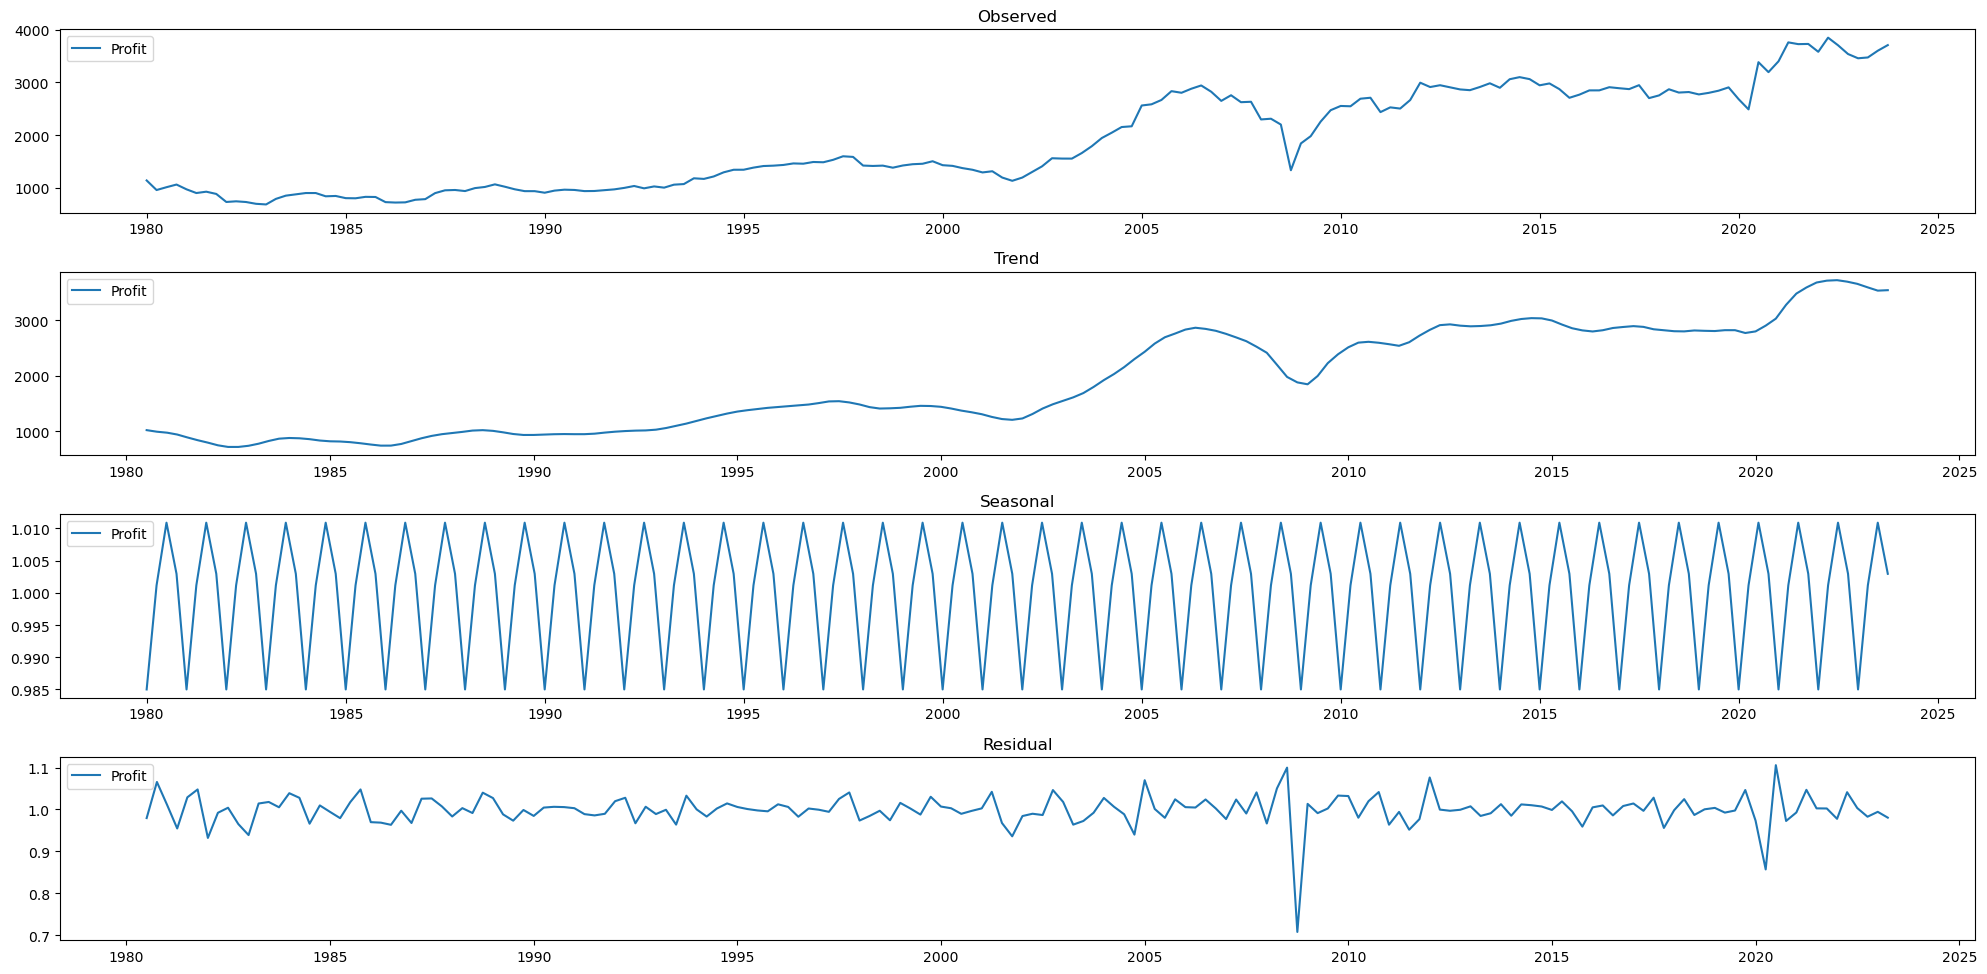

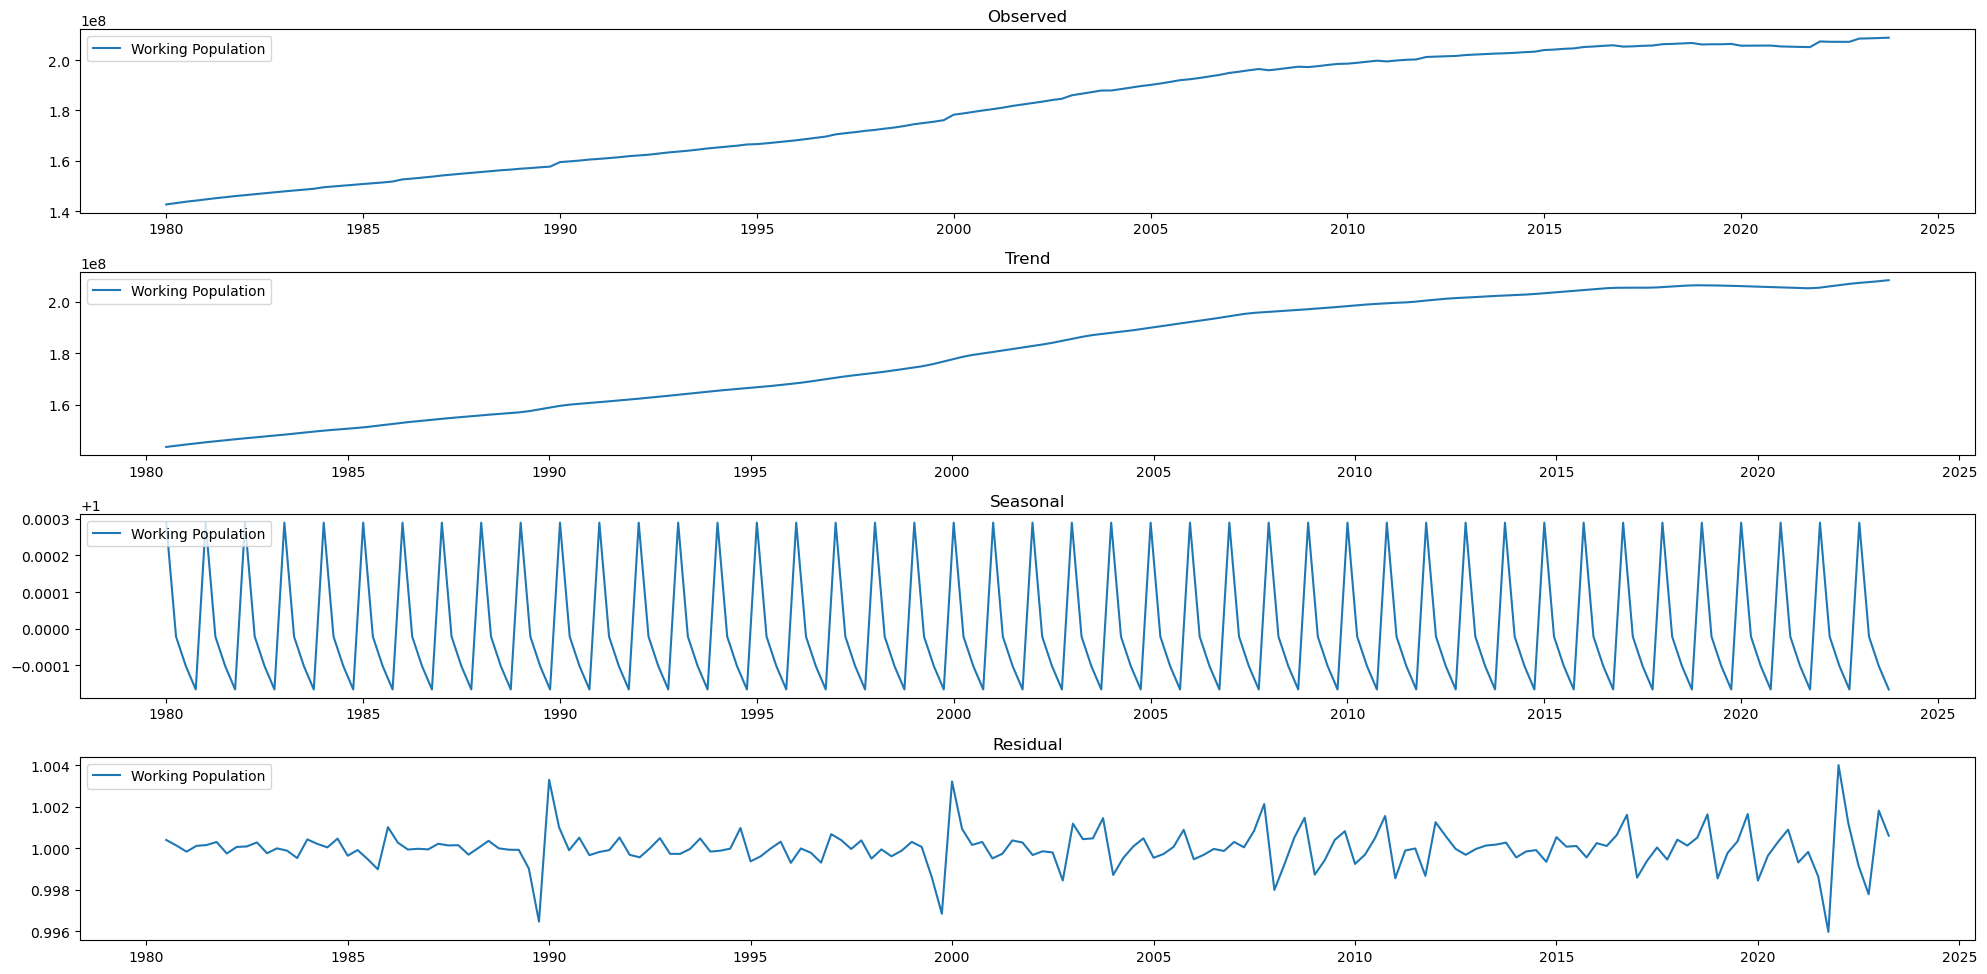

In [100]:
# Workers
perform_multi_STL(predictors_df, ['Profit'])              # Trend looks linear, but we used multiplicative for the sake of consistency (Profit and Working Pop both look linearish)
perform_multi_STL(predictors_df, ['Working Population'])  # Trend looks linear, but we used multiplicative for the sake of consistency


In [101]:

print(merged_df)




                     SO2    Auto Gas  Manufacturing  Petrol Coal       Profit  \
Date                                                                            
1980-01-01  9.442626e-07   80.378294      46.805149    88.803466  1141.031335   
1980-04-01  9.340424e-07   74.045325      45.293618    82.028254   959.105013   
1980-07-01  9.258992e-07   73.681244      43.621773    80.131477  1012.712596   
1980-10-01  9.199498e-07   73.421459      45.854066    80.748748  1063.103059   
1981-01-01  9.140747e-07   73.734122      45.590844    79.559832   972.401627   
...                  ...         ...            ...          ...          ...   
2022-10-01  3.424376e-07   98.531831      99.729927    97.423327  3538.278898   
2023-01-01  3.424159e-07   95.767037      99.867739    93.966345  3457.564000   
2023-04-01  3.424292e-07  101.908704     100.835622   101.857295  3473.110000   
2023-07-01  3.424477e-07  101.979881      99.776331   103.262438  3600.621000   
2023-10-01  3.424376e-07  10

In [102]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# Step 1: Separate target variable and predictors
X = merged_df.drop(columns=['SO2'])
y = merged_df['SO2']

# Step 2: Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply Ridge regularization
ridge = Ridge(alpha=1.0)  # You can adjust the regularization strength (alpha) as needed
ridge.fit(X_scaled, y)

# Step 4: Evaluate the model (optional)
# For example, you can check the coefficients of the Ridge model
print("Ridge Coefficients:", ridge.coef_)


Ridge Coefficients: [-4.10387435e-09 -7.34892335e-08  7.55560205e-09  2.65935709e-08
 -1.59201137e-07]


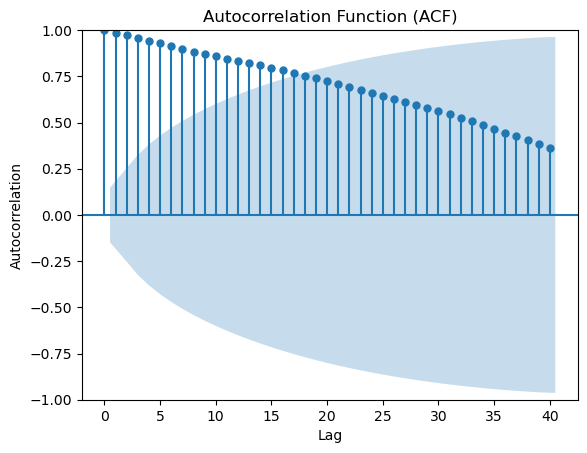

In [103]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot autocorrelation function (ACF)
plot_acf(merged_df['SO2'], lags=40)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF)')
plt.show()


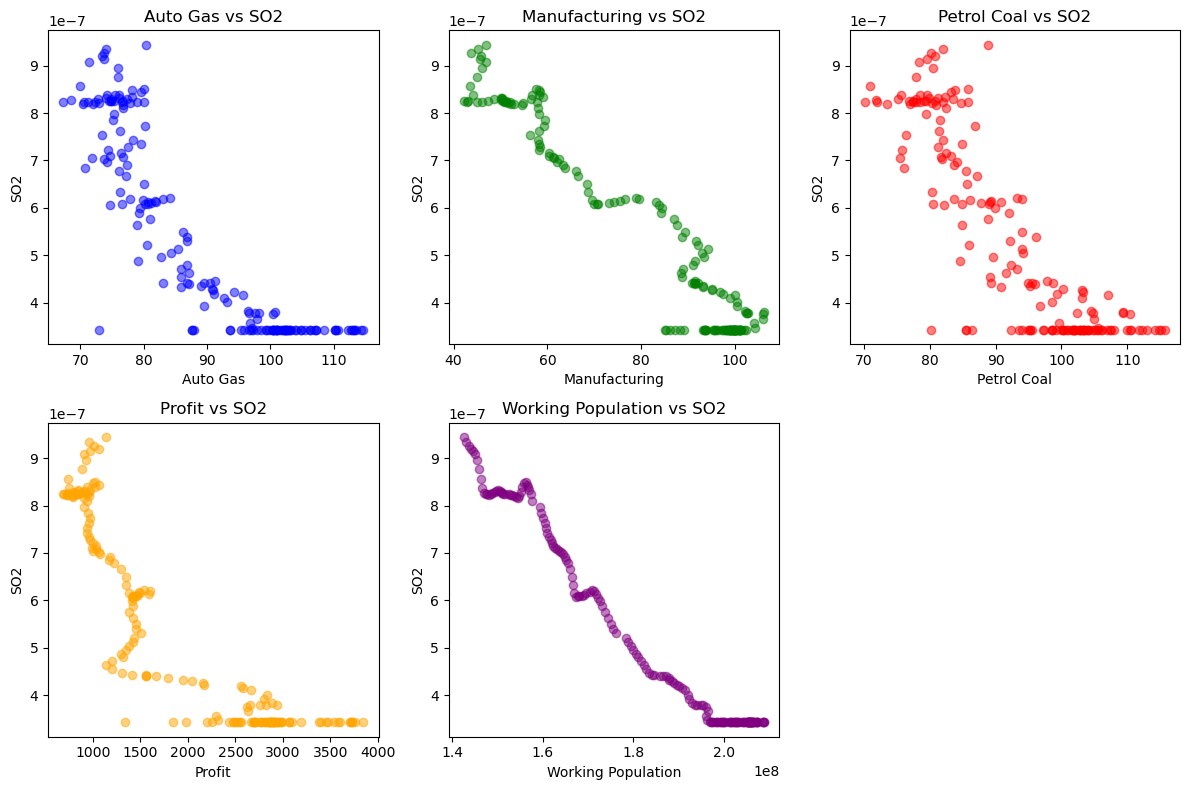

In [104]:
# Generate scatter plots
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.scatter(merged_df['Auto Gas'], merged_df['SO2'], color='blue', alpha=0.5)
plt.xlabel('Auto Gas')
plt.ylabel('SO2')
plt.title('Auto Gas vs SO2')

plt.subplot(2, 3, 2)
plt.scatter(merged_df['Manufacturing'], merged_df['SO2'], color='green', alpha=0.5)
plt.xlabel('Manufacturing')
plt.ylabel('SO2')
plt.title('Manufacturing vs SO2')

plt.subplot(2, 3, 3)
plt.scatter(merged_df['Petrol Coal'], merged_df['SO2'], color='red', alpha=0.5)
plt.xlabel('Petrol Coal')
plt.ylabel('SO2')
plt.title('Petrol Coal vs SO2')

plt.subplot(2, 3, 4)
plt.scatter(merged_df['Profit'], merged_df['SO2'], color='orange', alpha=0.5)
plt.xlabel('Profit')
plt.ylabel('SO2')
plt.title('Profit vs SO2')

plt.subplot(2, 3, 5)
plt.scatter(merged_df['Working Population'], merged_df['SO2'], color='purple', alpha=0.5)
plt.xlabel('Working Population')
plt.ylabel('SO2')
plt.title('Working Population vs SO2')

plt.tight_layout()
plt.show()


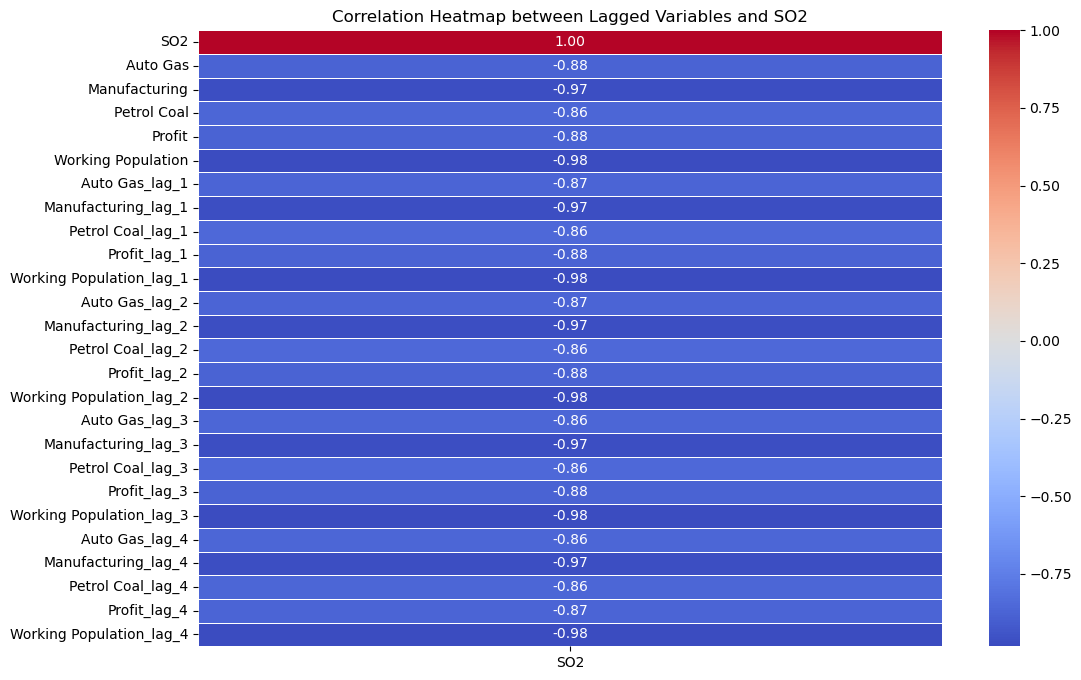

In [105]:
# Define the lag periods
lags = [1, 2, 3, 4]  # you can adjust the lag periods as needed

# Create lagged variables for each feature
for lag in lags:
    merged_df[f'Auto Gas_lag_{lag}'] = merged_df['Auto Gas'].shift(lag)
    merged_df[f'Manufacturing_lag_{lag}'] = merged_df['Manufacturing'].shift(lag)
    merged_df[f'Petrol Coal_lag_{lag}'] = merged_df['Petrol Coal'].shift(lag)
    merged_df[f'Profit_lag_{lag}'] = merged_df['Profit'].shift(lag)
    merged_df[f'Working Population_lag_{lag}'] = merged_df['Working Population'].shift(lag)

# # Drop rows with NaN values introduced by the shifting
# merged_df.dropna(inplace=True)
# Compute correlation matrix
lagged_correlation_matrix = merged_df.corr()

# Display correlation matrix
# print(lagged_correlation_matrix['SO2'])

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(lagged_correlation_matrix[['SO2']], annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap between Lagged Variables and SO2')
plt.show()


# Modeling: Only historical SO2

In [123]:
import pandas as pd
import numpy as np
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

def train_test_split_data(data, test_size=0.2):
    """Split the data into training and testing sets."""
    train_size = int(len(data) * (1 - test_size))
    train_data, test_data = data[:train_size], data[train_size:]
    return train_data, test_data

def find_best_arima_params(train_data, test_data, p_range, d_range, q_range):
    """Find the best ARIMA parameters using grid search."""
    param_combinations = list(itertools.product(p_range, d_range, q_range))
    best_params = None
    best_rmse = float('inf')
    
    for params in param_combinations:
        p, d, q = params
        arima_model = ARIMA(train_data, order=(p, d, q))
        arima_result = arima_model.fit()
        forecast_values = arima_result.forecast(steps=len(test_data))
        rmse = np.sqrt(mean_squared_error(test_data, forecast_values))
        
        if rmse < best_rmse:
            best_params = params
            best_rmse = rmse
    
    return best_params

def train_test_arima_model(train_data, test_data, best_params):
    """Train and test ARIMA model with the best parameters."""
    arima_model = ARIMA(train_data, order=best_params)
    arima_result = arima_model.fit()
    forecast_values = arima_result.forecast(steps=len(test_data))
    return forecast_values

def calculate_metrics(actual, forecast):
    """Calculate MAE, RMSE, MAPE, and MASE."""
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    mase = mae / np.mean(np.abs(np.diff(actual)))  # Using MAE of differences as denominator for MASE
    return mae, rmse, mape, mase

def repeated_cross_validate_arima_model(data, p_range, d_range, q_range, n_splits=5, n_repeats=30):
    """Perform repeated time series cross-validation for ARIMA model."""
    all_metrics = []

    for i in range(n_repeats):
        np.random.seed(i)  # Setting random seed for reproducibility
        tscv = TimeSeriesSplit(n_splits=n_splits)
        metrics = []

        for train_index, test_index in tscv.split(data):
            train_data, test_data = data[train_index], data[test_index]

            best_params = find_best_arima_params(train_data, test_data, p_range, d_range, q_range)
            forecast_values = train_test_arima_model(train_data, test_data, best_params)

            mae, rmse, mape, mase = calculate_metrics(test_data, forecast_values)
            metrics.append([mae, rmse, mape, mase])

        # Calculate the average of each metric across cross-validation folds
        avg_metrics = np.mean(metrics, axis=0)
        all_metrics.append(avg_metrics)

    # Convert the average metrics into a DataFrame
    df_metrics = pd.DataFrame(all_metrics, columns=['MAE', 'RMSE', 'MAPE', 'MASE'])
    return df_metrics


# Load your dataset
# merged_df = pd.read_csv('your_dataset.csv')

# Assuming 'merged_df' contains the merged dataset.
so2_data = merged_df['SO2'].values
p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)
n_splits = 5
n_repeats = 30

df_metrics = repeated_cross_validate_arima_model(so2_data, p_range, d_range, q_range, n_splits, n_repeats)

# Output the DataFrame of metrics
print(df_metrics)




/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/kevinmo

             MAE          RMSE      MAPE      MASE
0   2.541752e-08  3.035418e-08  4.241729  4.056443
1   2.541752e-08  3.035418e-08  4.241729  4.056443
2   2.541752e-08  3.035418e-08  4.241729  4.056443
3   2.541752e-08  3.035418e-08  4.241729  4.056443
4   2.541752e-08  3.035418e-08  4.241729  4.056443
5   2.541752e-08  3.035418e-08  4.241729  4.056443
6   2.541752e-08  3.035418e-08  4.241729  4.056443
7   2.541752e-08  3.035418e-08  4.241729  4.056443
8   2.541752e-08  3.035418e-08  4.241729  4.056443
9   2.541752e-08  3.035418e-08  4.241729  4.056443
10  2.541752e-08  3.035418e-08  4.241729  4.056443
11  2.541752e-08  3.035418e-08  4.241729  4.056443
12  2.541752e-08  3.035418e-08  4.241729  4.056443
13  2.541752e-08  3.035418e-08  4.241729  4.056443
14  2.541752e-08  3.035418e-08  4.241729  4.056443
15  2.541752e-08  3.035418e-08  4.241729  4.056443
16  2.541752e-08  3.035418e-08  4.241729  4.056443
17  2.541752e-08  3.035418e-08  4.241729  4.056443
18  2.541752e-08  3.035418e-08 

/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/b

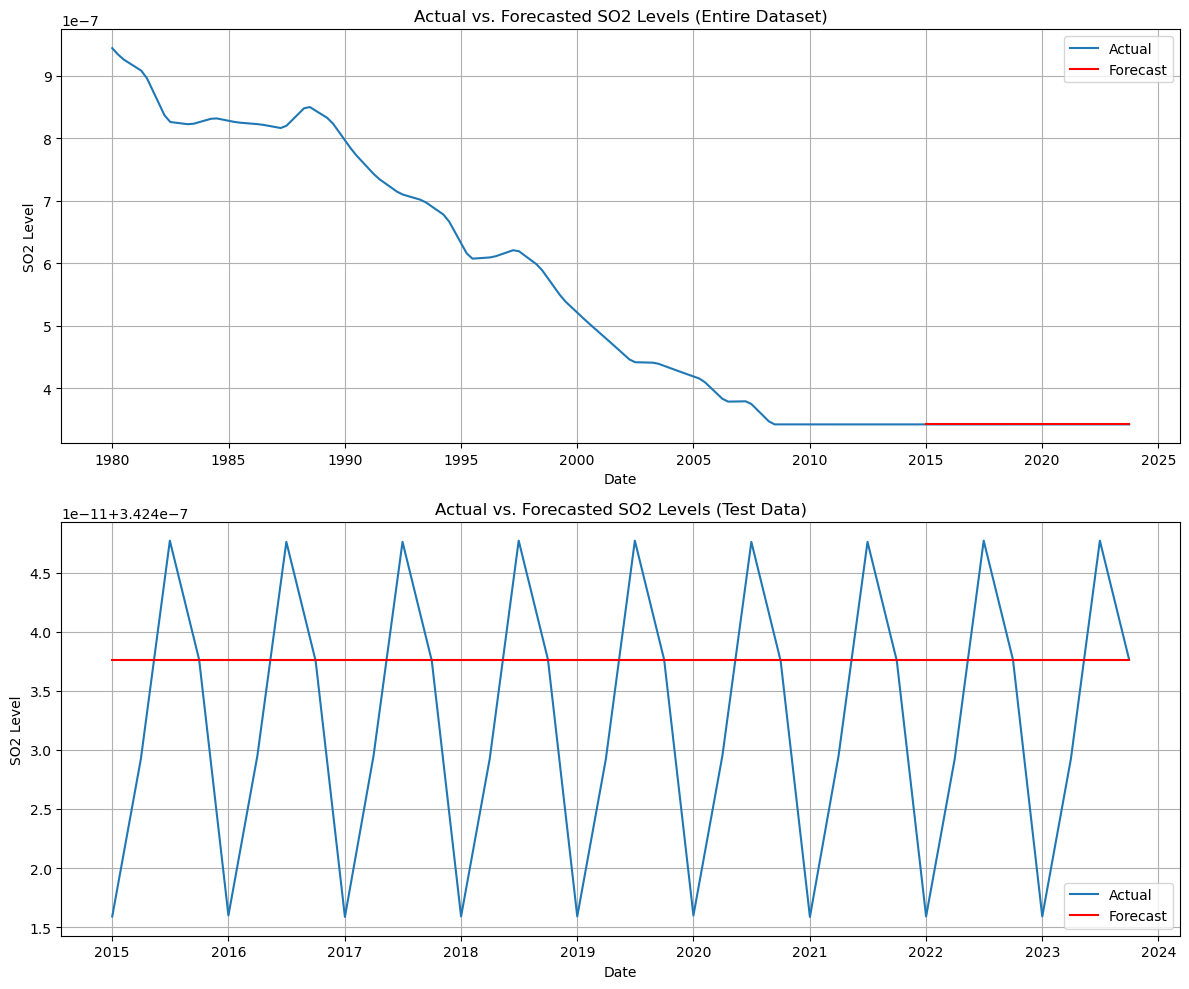

/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.p

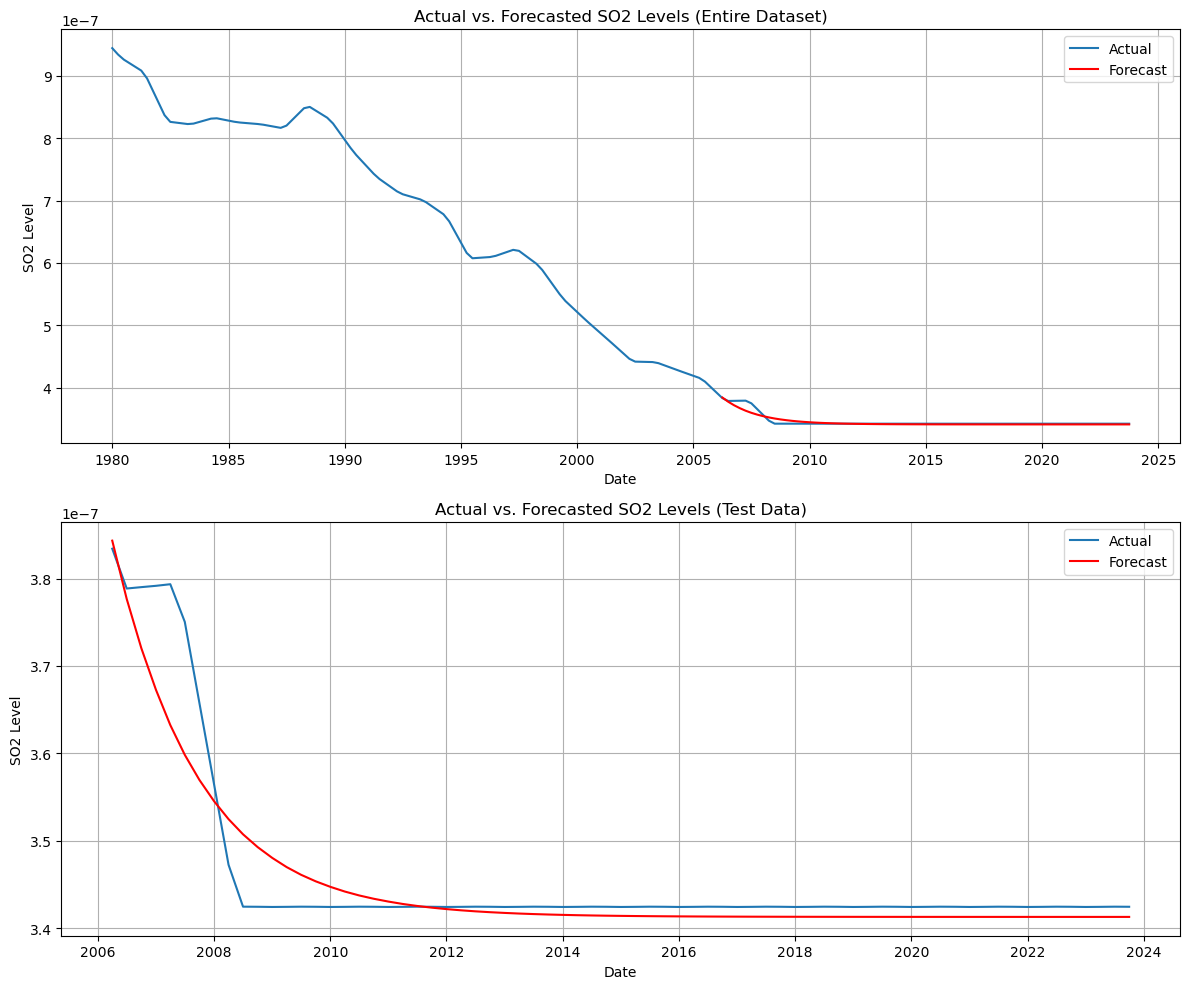

In [ ]:
# Define train-test split ratios
split_ratios = [(0.8, 0.2), (0.6, 0.4)]

for split_ratio in split_ratios:
    train_size, test_size = split_ratio
    train_data, test_data = train_test_split_data(so2_data, test_size=test_size)
    p_range = range(0, 3)
    d_range = range(0, 2)
    q_range = range(0, 3)
    best_params, _ = find_best_arima_params(train_data, test_data, p_range, d_range, q_range)
    forecast_values = train_test_arima_model(train_data, test_data, best_params)

    # Figure 1: Entire Dataset with Forecast
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Plot entire dataset with forecast
    axs[0].plot(so2_data.index, so2_data, label='Actual')
    axs[0].plot(test_data.index, forecast_values, label='Forecast', color='red')
    axs[0].set_title('Actual vs. Forecasted SO2 Levels (Entire Dataset)')
    axs[0].set_xlabel('Date')
    axs[0].set_ylabel('SO2 Level')
    axs[0].legend()
    axs[0].grid(True)

    # Plot dataset and forecast for the forecasted range
    axs[1].plot(test_data.index, test_data, label='Actual')
    axs[1].plot(test_data.index, forecast_values, label='Forecast', color='red')
    axs[1].set_title('Actual vs. Forecasted SO2 Levels (Test Data)')
    axs[1].set_xlabel('Date')
    axs[1].set_ylabel('SO2 Level')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()



# ARIMAX: Multiple Predictors